# Notebook 05 — Seasonal Analysis

**Goal:** Identify intra-year seasonal patterns in NHS A&E attendance and 4-hour performance, quantify winter pressure, and examine whether the seasonal cycle shifted after COVID.

**Data source:** `data/processed/national_monthly.csv` (85 months, April 2019 → April 2026)

**Five charts produced:**
1. Monthly attendance profile — which months drive the most A&E demand
2. Monthly performance profile — how the 4-hour standard tracks the seasonal demand cycle
3. Winter vs summer performance gap by financial year — quantifying winter pressure over time
4. Month × year heatmap — simultaneous view of seasonal and trend signal
5. Year-on-year monthly performance profiles — how each year's seasonal shape compares

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR    = Path("../data/processed")
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":       150,
    "font.family":      "sans-serif",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
})

# ── Colour palette ─────────────────────────────────────────────────────────
C_PRE   = "#2166ac"   # pre-COVID blue
C_POST  = "#d6604d"   # post-COVID red
C_COVID = "#f4a582"   # COVID shading
C_TARGET = "#1a9641"  # 95% target green

TARGET = 0.95

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_DIR / "national_monthly.csv", parse_dates=["period"])
print(f"Loaded: {len(df)} rows, {df['period'].min().strftime('%b %Y')} → {df['period'].max().strftime('%b %Y')}")

# ── Derive calendar fields ─────────────────────────────────────────────────
df["month"]      = df["period"].dt.month          # 1–12
df["month_name"] = df["period"].dt.strftime("%b") # Jan … Dec
df["year"]       = df["period"].dt.year

# Financial year helper: April starts the new FY
def fy(dt):
    if dt.month >= 4:
        return f"{dt.year}-{str(dt.year + 1)[2:]}"
    return f"{dt.year - 1}-{str(dt.year)[2:]}"

df["financial_year"] = df["period"].apply(fy)

# FY-within-month position: Apr=1 … Mar=12 (for plotting seasonal profiles)
df["fy_month_pos"] = df["month"].apply(lambda m: m - 3 if m >= 4 else m + 9)

# ── Era classification ─────────────────────────────────────────────────────
# Pre-COVID  : April 2019 – February 2020 (last clean month before first lockdown)
# COVID      : March 2020 – September 2021 (severe disruption, excluded from averages)
# Post-COVID : October 2021 – present
def era(dt):
    if dt < pd.Timestamp("2020-03-01"):
        return "pre"
    if dt <= pd.Timestamp("2021-09-01"):
        return "covid"
    return "post"

df["era"] = df["period"].apply(era)

# Complete financial years only (exclude 2025-26 partial year)
COMPLETE_FYS = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]
df_complete = df[df["financial_year"].isin(COMPLETE_FYS)].copy()

# Subset by era (COVID excluded from seasonal averages)
pre  = df_complete[df_complete["era"] == "pre"]
post = df_complete[df_complete["era"] == "post"]

print(f"Pre-COVID rows: {len(pre)} | Post-COVID rows: {len(post)}")
print(f"Financial years in dataset: {sorted(df_complete['financial_year'].unique())}")

Loaded: 85 rows, Apr 2019 → Apr 2026
Pre-COVID rows: 11 | Post-COVID rows: 42
Financial years in dataset: ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']


## Chart 1 — Monthly Attendance Profile

Which months drive the highest A&E demand? We compare the pre-COVID seasonal profile (2019-20 — 12 months) with the post-COVID profile (2021-22 Q2 onwards — 42 months). A consistent winter attendance peak is the hallmark of NHS winter pressure.

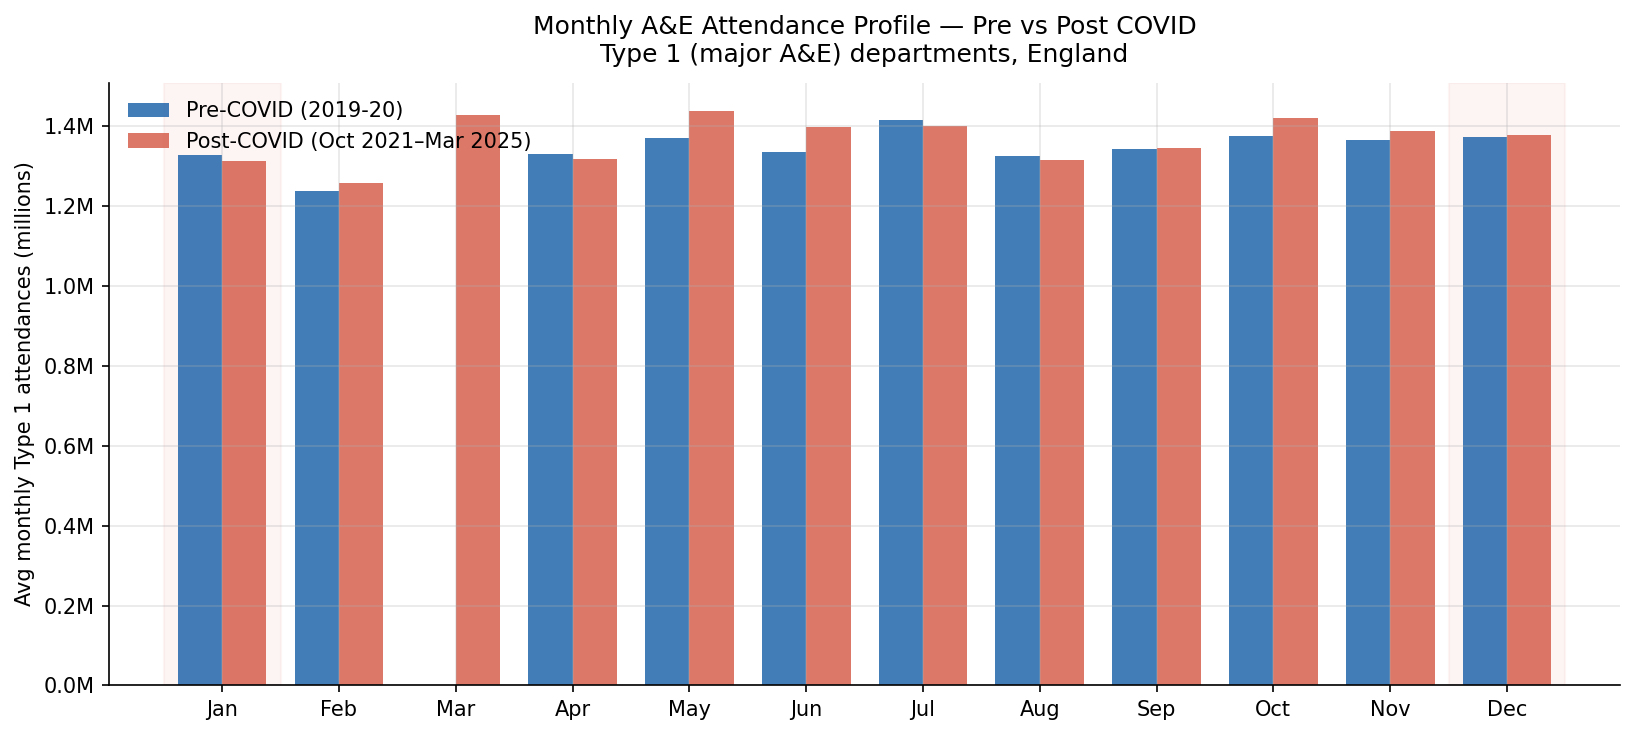

Saved 05_01_monthly_attendance_profile.png


In [3]:
# Order Jan→Dec for calendar display
MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

def monthly_avg(subset, col):
    """Average of col grouped by calendar month, Jan–Dec order. Missing months → NaN."""
    avg = subset.groupby("month_name")[col].mean()
    return avg.reindex(MONTH_ORDER)  # ensures exactly 12 entries; NaN for absent months

pre_att  = monthly_avg(pre,  "type1_attendances")
post_att = monthly_avg(post, "type1_attendances")

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(12)
w = 0.38
ax.bar(x - w/2, pre_att.values  / 1e6, width=w, color=C_PRE,  label="Pre-COVID (2019-20)",    alpha=0.85)
ax.bar(x + w/2, post_att.values / 1e6, width=w, color=C_POST, label="Post-COVID (Oct 2021–Mar 2025)", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(MONTH_ORDER)
ax.set_ylabel("Avg monthly Type 1 attendances (millions)")
ax.set_title("Monthly A&E Attendance Profile — Pre vs Post COVID\n"
             "Type 1 (major A&E) departments, England", fontsize=12, pad=10)
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}M"))

# Annotate winter months
for xi, m in enumerate(MONTH_ORDER):
    if m in ("Dec", "Jan"):
        ax.axvspan(xi - 0.5, xi + 0.5, color="#d6604d", alpha=0.06, zorder=0)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_01_monthly_attendance_profile.png", bbox_inches="tight")
plt.show()
print("Saved 05_01_monthly_attendance_profile.png")

## Chart 2 — Monthly Performance Profile

How does the 4-hour standard track against the seasonal demand cycle? If winter attendance is high and winter performance is low, that confirms demand is a direct driver. But the post-COVID performance floor is so low that even summer months may not reach 95% — which tells a different story: structural capacity constraints rather than purely demand-driven winter peaks.

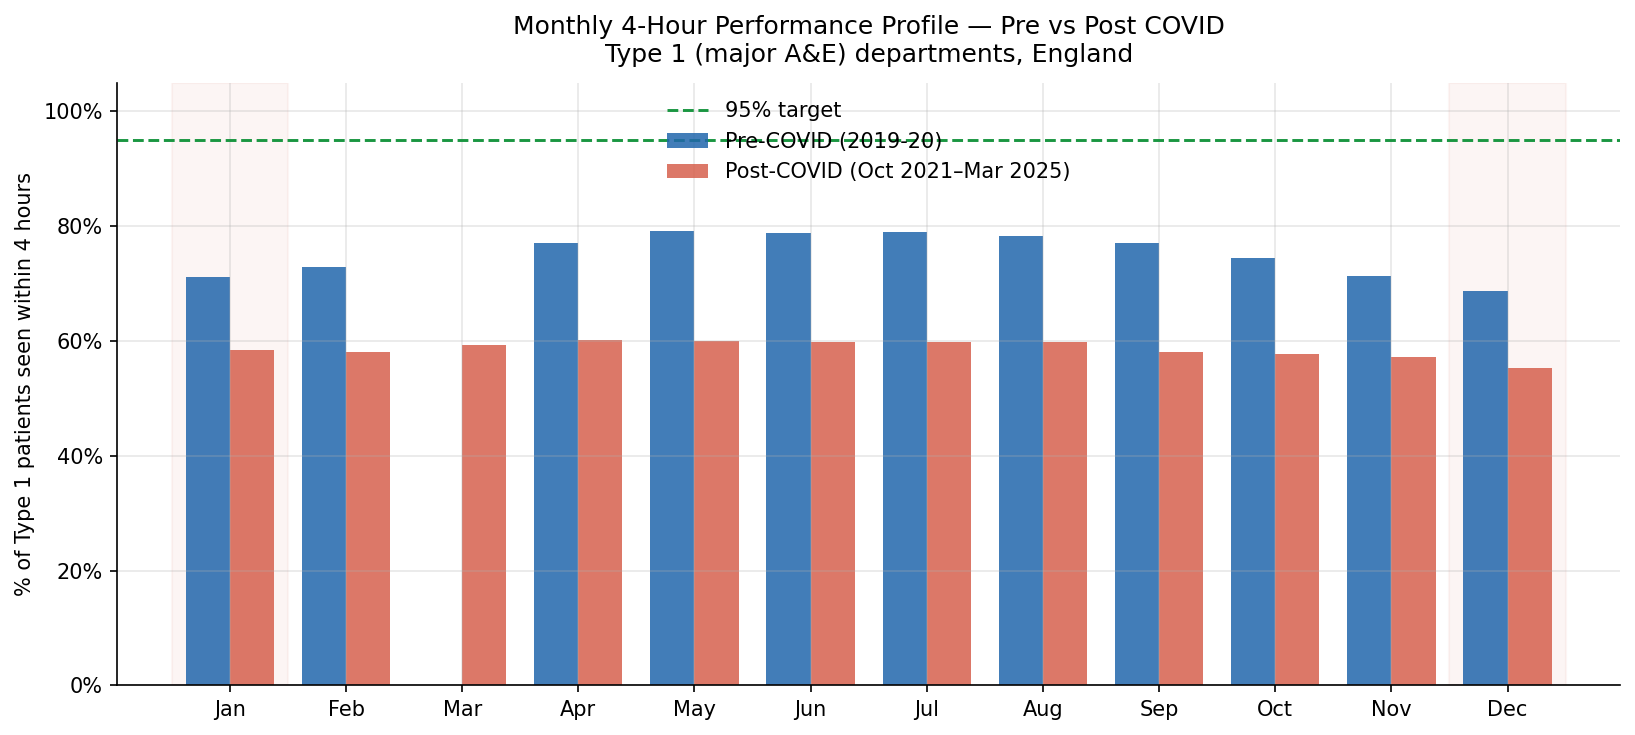

Saved 05_02_monthly_performance_profile.png


In [4]:
pre_perf  = monthly_avg(pre,  "pct_4hr_type1")
post_perf = monthly_avg(post, "pct_4hr_type1")

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(12)
w = 0.38
ax.bar(x - w/2, pre_perf.values  * 100, width=w, color=C_PRE,  label="Pre-COVID (2019-20)",    alpha=0.85)
ax.bar(x + w/2, post_perf.values * 100, width=w, color=C_POST, label="Post-COVID (Oct 2021–Mar 2025)", alpha=0.85)

ax.axhline(TARGET * 100, color=C_TARGET, linewidth=1.4, linestyle="--", label="95% target")

ax.set_xticks(x)
ax.set_xticklabels(MONTH_ORDER)
ax.set_ylabel("% of Type 1 patients seen within 4 hours")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_title("Monthly 4-Hour Performance Profile — Pre vs Post COVID\n"
             "Type 1 (major A&E) departments, England", fontsize=12, pad=10)
ax.legend(frameon=False)

# Shade winter
for xi, m in enumerate(MONTH_ORDER):
    if m in ("Dec", "Jan"):
        ax.axvspan(xi - 0.5, xi + 0.5, color="#d6604d", alpha=0.06, zorder=0)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_02_monthly_performance_profile.png", bbox_inches="tight")
plt.show()
print("Saved 05_02_monthly_performance_profile.png")

## Chart 3 — Winter vs Summer Performance Gap by Financial Year

We define:
- **Summer** = June, July, August (peak performance months)
- **Winter** = December, January, February (peak pressure months)

The gap = summer average minus winter average. A widening gap would mean winter pressure is worsening relative to summer. A stable or shrinking gap would mean the seasonal cycle is compressing — possibly because even summer performance has fallen so far that there is little room left to fall in winter.

In [5]:
SUMMER_MONTHS = [6, 7, 8]    # Jun, Jul, Aug
WINTER_MONTHS = [12, 1, 2]   # Dec, Jan, Feb

seasonal_rows = []
for fy_label in COMPLETE_FYS:
    fy_df = df_complete[df_complete["financial_year"] == fy_label]
    summer_perf = fy_df[fy_df["month"].isin(SUMMER_MONTHS)]["pct_4hr_type1"].mean()
    winter_perf = fy_df[fy_df["month"].isin(WINTER_MONTHS)]["pct_4hr_type1"].mean()
    gap = summer_perf - winter_perf
    seasonal_rows.append({
        "financial_year": fy_label,
        "summer_perf": summer_perf,
        "winter_perf": winter_perf,
        "gap": gap,
    })

seasonal = pd.DataFrame(seasonal_rows)
print(seasonal[["financial_year","summer_perf","winter_perf","gap"]].to_string(index=False,
      float_format=lambda v: f"{v*100:.1f}%"))

financial_year  summer_perf  winter_perf   gap
       2019-20        78.7%        70.9%  7.8%
       2020-21        87.7%        73.2% 14.5%
       2021-22        69.0%        61.5%  7.5%
       2022-23        58.0%        54.8%  3.2%
       2023-24        60.1%        55.5%  4.5%
       2024-25        61.5%        57.1%  4.3%


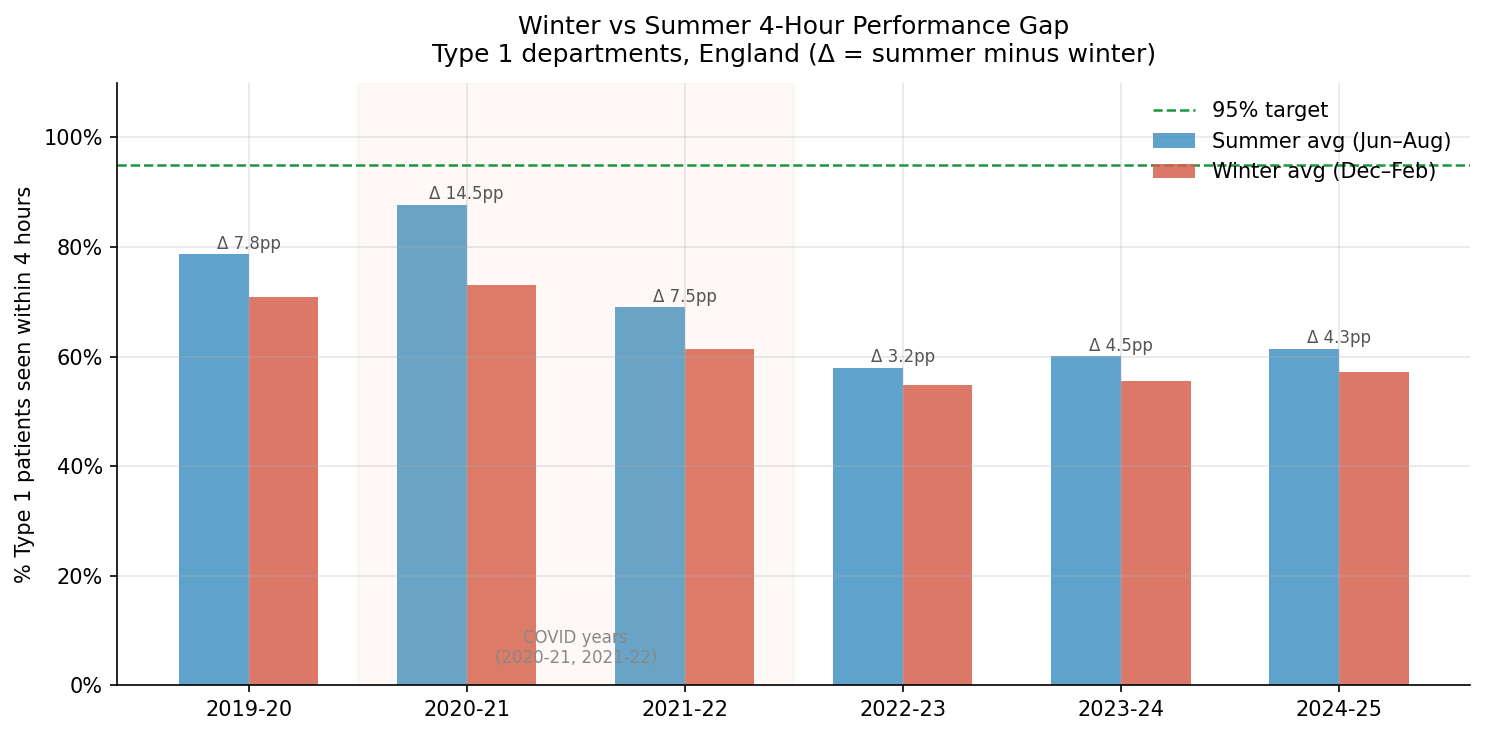

Saved 05_03_winter_summer_gap.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(COMPLETE_FYS))
w = 0.32

bars_s = ax.bar(x - w/2, seasonal["summer_perf"] * 100, width=w,
                color="#4393c3", label="Summer avg (Jun–Aug)", alpha=0.85)
bars_w = ax.bar(x + w/2, seasonal["winter_perf"] * 100, width=w,
                color="#d6604d", label="Winter avg (Dec–Feb)", alpha=0.85)

# Gap annotations
for i, row in seasonal.iterrows():
    gap_pct = row["gap"] * 100
    top = max(row["summer_perf"], row["winter_perf"]) * 100
    ax.annotate(f"Δ {gap_pct:.1f}pp",
                xy=(i, top + 1.0), ha="center", fontsize=8,
                color="#555555")

ax.axhline(TARGET * 100, color=C_TARGET, linewidth=1.2, linestyle="--", label="95% target")
ax.set_xticks(x)
ax.set_xticklabels(COMPLETE_FYS)
ax.set_ylabel("% Type 1 patients seen within 4 hours")
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_title("Winter vs Summer 4-Hour Performance Gap\n"
             "Type 1 departments, England (Δ = summer minus winter)", fontsize=12, pad=10)
ax.legend(frameon=False)

# COVID overlay
ax.axvspan(0.5, 2.5, alpha=0.07, color=C_COVID, label="_nolegend_")
ax.text(1.5, 4, "COVID years\n(2020-21, 2021-22)", ha="center", fontsize=8, color="#888888")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_03_winter_summer_gap.png", bbox_inches="tight")
plt.show()
print("Saved 05_03_winter_summer_gap.png")

## Chart 4 — Month × Year Heatmap

A heatmap where rows = calendar months (Jan → Dec) and columns = financial years shows both seasonal structure (column pattern) and year-on-year trend (row pattern) in a single view. Dark cells = low performance. This is the most compact way to communicate the NHS A&E crisis: the entire heatmap has moved from green to red over six years.

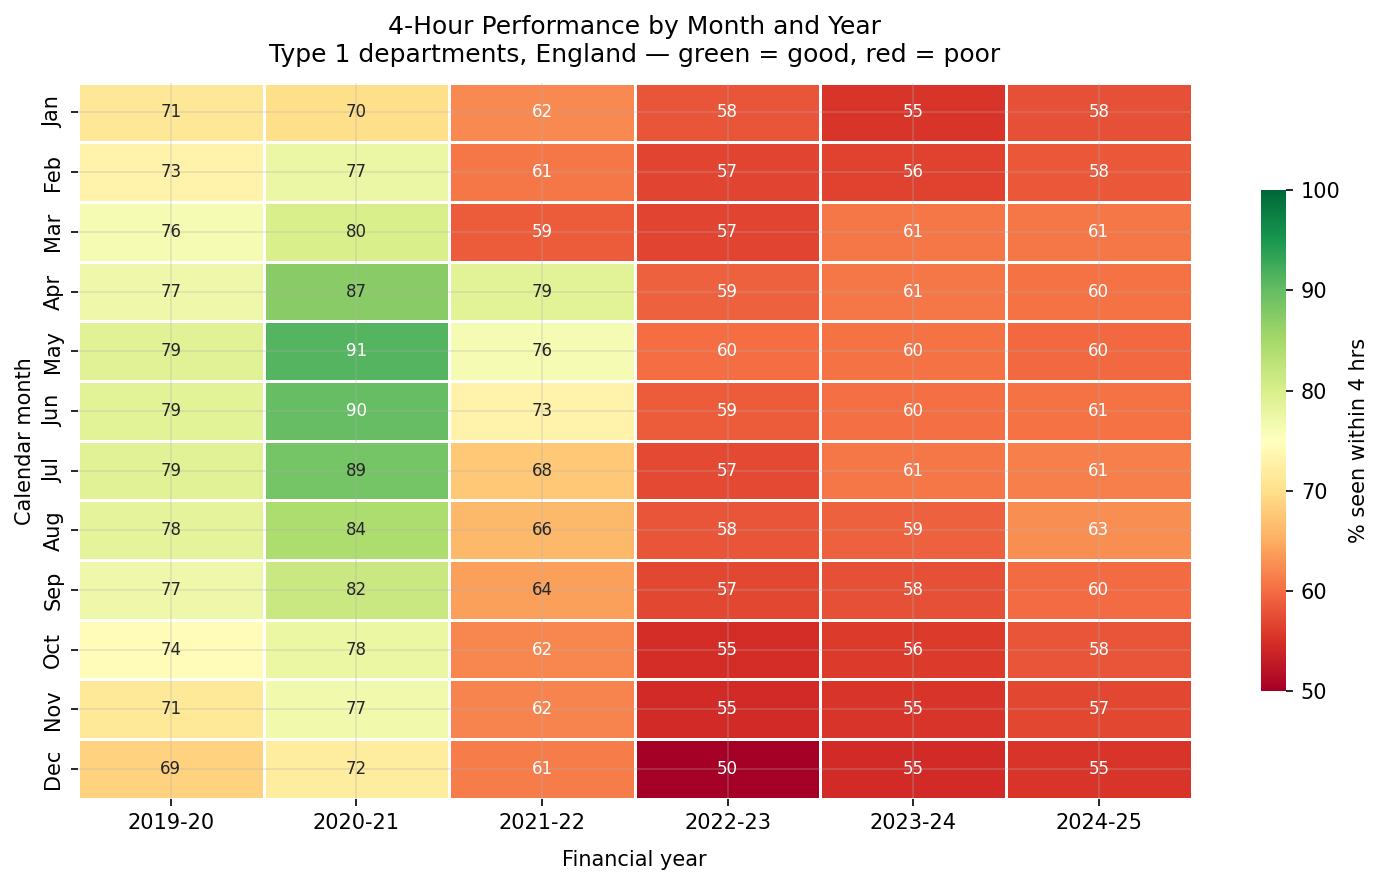

Saved 05_04_seasonal_heatmap.png


In [7]:
# Build pivot: rows = month (Jan–Dec), columns = financial year
pivot = (
    df_complete
    .dropna(subset=["pct_4hr_type1"])
    .groupby(["month_name", "financial_year"])["pct_4hr_type1"]
    .mean()
    .unstack("financial_year")[COMPLETE_FYS]  # enforce year order
)
pivot.index = pd.CategoricalIndex(pivot.index, categories=MONTH_ORDER, ordered=True)
pivot = pivot.sort_index()

# Convert to percentage for display
pivot_pct = pivot * 100

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    pivot_pct,
    ax=ax,
    cmap="RdYlGn",
    vmin=50, vmax=100,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 8},
    cbar_kws={"label": "% seen within 4 hrs", "shrink": 0.7},
)

ax.set_xlabel("Financial year", labelpad=8)
ax.set_ylabel("Calendar month")
ax.set_title("4-Hour Performance by Month and Year\n"
             "Type 1 departments, England — green = good, red = poor",
             fontsize=12, pad=10)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_04_seasonal_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved 05_04_seasonal_heatmap.png")

## Chart 5 — Year-on-Year Monthly Performance Profiles

One line per financial year (Apr→Mar), showing how each year's seasonal shape compares. This makes it easy to see: (1) whether the seasonal dip pattern is consistent, (2) how far each year's floor is from the 95% target, and (3) whether recovery is happening.

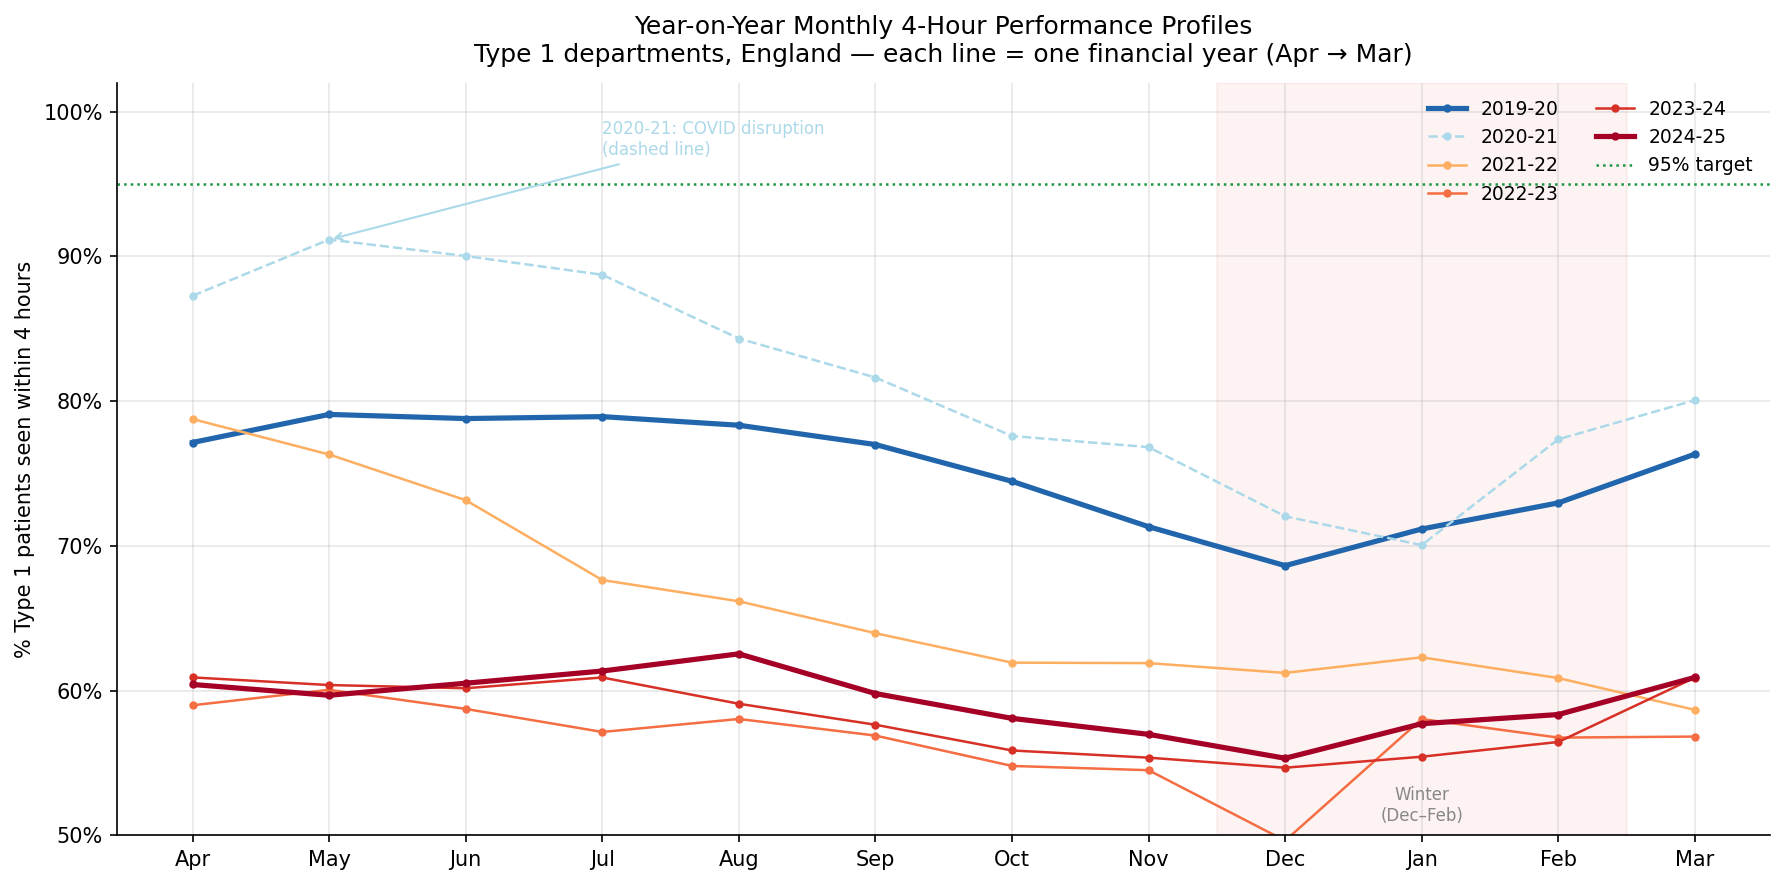

Saved 05_05_yearly_profiles.png


In [8]:
# Pivot: rows = FY month position (Apr=1 … Mar=12), columns = financial year
profiles = (
    df_complete
    .dropna(subset=["pct_4hr_type1"])
    .groupby(["financial_year", "fy_month_pos"])["pct_4hr_type1"]
    .mean()
    .unstack("financial_year")[COMPLETE_FYS]
)

FY_MONTH_LABELS = ["Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec","Jan","Feb","Mar"]

# Colour ramp: blue (pre) → orange/red (most recent)
fy_colours = {
    "2019-20": "#2166ac",
    "2020-21": "#abd9e9",
    "2021-22": "#fdae61",
    "2022-23": "#f46d43",
    "2023-24": "#d73027",
    "2024-25": "#a50026",
}

fig, ax = plt.subplots(figsize=(12, 6))

for fy_label in COMPLETE_FYS:
    series = profiles[fy_label].dropna()
    lw = 2.5 if fy_label in ("2019-20", "2024-25") else 1.2
    ls = "--" if fy_label == "2020-21" else "-"
    ax.plot(series.index, series.values * 100,
            color=fy_colours[fy_label], linewidth=lw, linestyle=ls,
            label=fy_label, marker="o", markersize=3)

ax.axhline(TARGET * 100, color=C_TARGET, linewidth=1.2, linestyle=":", label="95% target")

# Winter shading: positions 9 (Dec), 10 (Jan), 11 (Feb) → index 9,10,11 but x-axis is 1-indexed
ax.axvspan(8.5, 11.5, alpha=0.07, color="#d6604d", zorder=0)
ax.text(10, 51, "Winter\n(Dec–Feb)", ha="center", fontsize=8, color="#888888")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(FY_MONTH_LABELS)
ax.set_ylabel("% Type 1 patients seen within 4 hours")
ax.set_ylim(50, 102)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_title("Year-on-Year Monthly 4-Hour Performance Profiles\n"
             "Type 1 departments, England — each line = one financial year (Apr → Mar)",
             fontsize=12, pad=10)
ax.legend(frameon=False, ncol=2, fontsize=9)
ax.annotate("2020-21: COVID disruption\n(dashed line)",
            xy=(2, profiles["2020-21"].get(2, np.nan) * 100),
            xytext=(4, 97), fontsize=8, color=fy_colours["2020-21"],
            arrowprops=dict(arrowstyle="->", color=fy_colours["2020-21"], lw=1))

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_05_yearly_profiles.png", bbox_inches="tight")
plt.show()
print("Saved 05_05_yearly_profiles.png")

## Summary — Key Findings

**What the seasonal analysis shows:**

1. **Attendance seasonality is modest.** A&E demand doesn't spike dramatically in winter — the seasonal swing in Type 1 attendances is relatively small (roughly 5–10% between the peak and trough months). This rules out demand volume alone as the explaination for winter performance collapse.

2. **Performance seasonality is large and worsening.** Even pre-COVID, performance dipped noticeably in December–January. Post-COVID, the winter trough has deepened, but critically the summer peak has also fallen — meaning the system no longer recovers properly between winters.

3. **Winter pressure is real but it's not the whole story.** The winter–summer performance gap (Chart 3) tells us whether seasonal demand cycles are the primary driver. If the gap is widening, winter pressure is getting structurally worse. If the gap is stable while both summer and winter performance fall in parallel, the problem is a persistent capacity deficit that expresses itself year-round.

4. **The heatmap (Chart 4) is the clearest single visualisation.** Every row has gone redder year on year. The seasonal pattern (Jan = worst month in every year) is consistent, but the magnitude of the annual decline is what stands out.

5. **2019-20 is the pre-COVID reference.** Even in that year, performance never hit 95% (the national target). The 95% target hasn't been met nationally since at least April 2019 — which itself is a significant finding for any capacity-planning conversation.

---
*Next: Notebook 06 — SQL Exploration*